# Adding water vapor feedback to the grey model of the atmosphere

#### Acknowledgments: This notebook borrows material from lecture notes of Geoff Vallis (university of Exeter) and Simona Bordoni (University of Trento)

You will recall from atmospheric physics that in the $n$ layer *black* body atmosphere we showed that the relationship between the surface temperature and the effective emitting temperature was 

$$
T^4_s=(n+1)T^4_e
$$

Thus as $n\rightarrow \infty$ then $T_s \rightarrow \infty$.  For a grey body atmosphere, instead, there is a finite solution. We can approximate this term in the energy balance equation by writing OLR term for the multilevel grey body model as :
  
$$
  C \frac{dT_s}{dt} = \frac{S_0}{4} [ 1 - \alpha(T_s)]  -  \frac{1}{1+\tau/2}\sigma T_s^4
$$
When $\tau=0$ this reduces to the simple energy balance model with a transparent atmosphere, $T_s$ then increases with $\tau$ as expected from an increasing greenhouse effect, and then as $\tau \rightarrow \infty$ the equations blows up and there is no solution for $T_s$!

We will specify the optical depth as a temperature-dependent function that represents the increase of water vapor specific humidity with temperature added to a constant value that represents the effects of clouds and other greenhouse gases:
 
 \begin{equation}
  \tau = \tau_{co2}+\tau_{wv}=1.12 + 0.14 \exp \big [ - \frac{L_v}{R_v}  \big( \frac{1}{T} - \frac{1}{288} \big ) \big ] 
  \end{equation}

 $\tau(T)$ includes a part that is constant (greenhouse gases and clouds) and a variable part that is proportional to water vapor pressure.  Remember that $R_v = 461.5$ J kg$^{-1}$ K$^{-1}$ and $L_v = 2.5 \times 10^6$ J kg$^{-1}$.

In [1]:
# packages needed in the notebook
import matplotlib.pyplot as plt
import numpy as np

# define constants
Lv=2.5e6
Rv=461.5
sigma=5.67e-8
tauco2=1.12

We now define the functions for the optical depth:

In [2]:
def tauwv(T,fac=0.14):
    """optical depth as function of surface temperature DUE to WATER VAPOR"""
    return fac*np.exp(-Lv*(1/T-1/288)/Rv)

def tau(T,fac=0.14):
    return tauco2+tauwv(T,fac=fac)

# vector of surface temperatures
Ts=np.arange(260,320,5)
print(Ts)
print(tau(Ts))

[260 265 270 275 280 285 290 295 300 305 310 315]
[1.13846747 1.14736118 1.15995205 1.17753935 1.20179613 1.23485246
 1.27939138 1.33875843 1.41708549 1.51942952 1.65192673 1.82196248]


Now let's make a plot of Tau as a function of the surface temperature

Text(0, 0.5, 'Optical Depth ($\\tau$)')

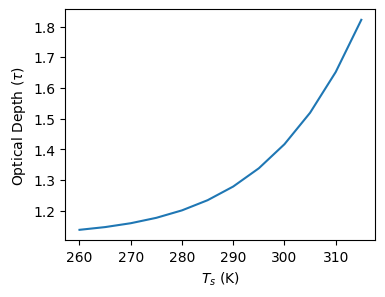

In [3]:

# plot Tau
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(Ts,tau(Ts))
ax.set_xlabel("$T_s$ (K)")
ax.set_ylabel("Optical Depth ($\\tau$)")


What do you notice about the shape of the curve?  

The optical depth is a highly non linear function and increasing rapidly with surface temperature, why is this?

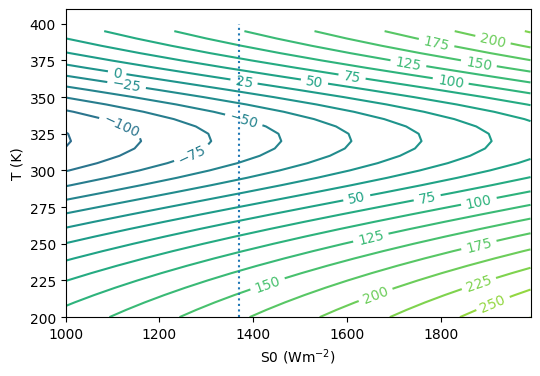

In [4]:
# surface albedo with ice feedback included, turned off by default
def alfa(T,lconst=True):
    if lconst: 
        albedo=0.33    
    else:
        albedo=0.45-0.25*np.tanh((T-272)/23)
    return albedo 

def cdTdt(S,T):
    """define the energy balance equation in a function"""
    vtau=tau(T)
    return S*(1-alfa(T))/4 - (1/(1+tau(T)/2))*sigma*np.power(T,4)


# define the solar constant array
S0=np.arange(1000,2000,10)
Ts=np.arange(200,400,5)

T2d=np.tile(Ts,(len(S0),1)).transpose()
S2d=np.tile(S0,(len(Ts),1))


# contour plot
fig,ax=plt.subplots(figsize=(6,4))
X=ax.contour(S2d,T2d,cdTdt(S2d,T2d),levels=np.arange(-400,400,25))
ax.clabel(X,fontsize=10)
ax.set_xlabel("S0 (Wm$^{-2}$)")
ax.set_ylabel("T (K)")

S0today=1370.
ax.vlines(S0today,200,400,linestyles="dotted")

## Exercises and Questions to consider: 

1. Take today's climate $S_0$, what is the equilibrium temperature?

2. Let's perturb $S_0$ to 1400 W m $^{-2}$, what happens to the temperature?

3. At what value of the solar constant does the system become unstable?

4. What is the physics of this instability?

Congratulations, you have discovered what is known as the runaway greenhouse effect, first coined by Ingersoll (82). We will discuss the physics of this in class. 

## Exercises on the climate feedback

1. Without looking at the next section, attempt to derive the water vapor climate feedback factor $\lambda_{wv}$ in this model for present day $S_0$.  
2. Is the feedback positive or negative, and do you understand why?
3. The feedback seems to be weaker than the value derived from GCMs.  To what do you need to change the factor 0.14 to in order to get a feedback of 2.0 W m$^{-2}$ K$^{-1}$?  How would that revised value change the equilibrium climate for today's solar forcing?


## Feedback factor 

We recall that the climate feedback factor is the partial derivative of the TOA fluxes with respect to the surface temperature, changing only the parameter in question, in this case water vapour.

$$
\frac{\partial N}{\partial \tau} \frac{\partial \tau}{\partial T_s} = \frac{2\sigma T_s^4}{(2+\tau)^2} \frac{\partial \tau}{\partial T_s}
$$

$$
\frac{d\tau}{dT_s}=0.14 \exp \big [ - \frac{L_v}{R_v}  \big( \frac{1}{T_s} - \frac{1}{288} \big ) \big ] \frac{L_v} {R_v T_s^2}=\tau_{wv}(T)\frac{L_v} {R_v T_s^2}
$$

Note, you can also derive the total substantive derivative of $N$ and then subtract the Planck feedback, you should arrive at the approximately same answer (try it and see!):


water vapour feedback for 288  =  0.6712111602786375  W m$^{-2}$ K^-1


Text(0, 0.5, 'WV Feedback $\\lambda_{wv}$ (W m$^{-2}$ K$^{-1}$)')

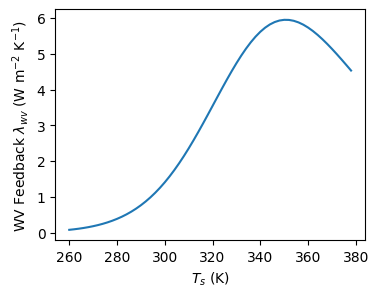

In [5]:
def dtaudT(T,fac=0.14):
    """optical depth as function of surface temperature"""
    LoR=Lv/Rv
    return tauwv(T,fac=fac)*LoR/(T*T)

Ts=288
lamwv=dtaudT(Ts,fac=0.14)*2*sigma*np.power(Ts,4)/np.power(2+tau(Ts),2)
print ("water vapour feedback for",Ts," = ",lamwv," W m$^{-2}$ K^-1")

Ts=np.arange(260,380,2)
lamwv=dtaudT(Ts,fac=0.14)*2*sigma*np.power(Ts,4)/np.power(2+tau(Ts),2)
fig,ax=plt.subplots(figsize=(4,3))
ax.plot(Ts,lamwv)
ax.set_xlabel("$T_s$ (K)")
ax.set_ylabel("WV Feedback $\\lambda_{wv}$ (W m$^{-2}$ K$^{-1}$)")


## Water vapour feedback in climlab

So we have seen from the above very simple model that water vapor feedback in positive.  Now we will attempt to calculate it using climlab that implements a full radiative scheme RRTM which is also used in full physics climate models. 

This follows on from the notebook on RCE from the first terms course 

First let's import the packages we need.



In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from metpy.plots import SkewT
import climlab
import requests
import os

define a couple of helper functions to plot a skew-T graph. 

In [35]:

#  Resuable function to plot the temperature data on a Skew-T chart
def make_skewT():
    fig = plt.figure(figsize=(9, 9))
    skew = SkewT(fig, rotation=30)
    skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
    skew.ax.set_ylim(1050, 10)
    skew.ax.set_xlim(-90, 45)
    # Add the relevant special lines
    skew.plot_dry_adiabats(linewidth=0.5)
    skew.plot_moist_adiabats(linewidth=0.5)
    #skew.plot_mixing_lines()
    skew.ax.legend()
    skew.ax.set_xlabel('Temperature (degC)', fontsize=14)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=14)
    return skew

#  and a function to add extra profiles to this chart
def add_profile(skew, model, linestyle='-', color=None):
    line = skew.plot(model.lev, model.Tatm - climlab.constants.tempCtoK,
             label=model.name, linewidth=2)[0]
    skew.plot(1000, model.Ts - climlab.constants.tempCtoK, 'o', 
              markersize=8, color=line.get_color())
    skew.ax.legend()

Now we read in T and specific humidity from climadods - these are simply ERA5 climatologies

In [36]:
# Note: Ensure the URL points to the actual .nc file download
url = "http://clima-dods.ictp.it/Users/tompkins/diploma/data/"
files=["tmean3.nc","qvmean3.nc"]
target="../data/"
for file in files:
    # 2. Download the file if it doesn't exist on your disk yet
    if not os.path.exists(target+file):
        print(f"Downloading {file}...")
        r = requests.get(url+file, stream=True)
        r.raise_for_status()
        with open(target+file, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    else:
        print("Files present")

Files present
Files present


read them in ....

In [37]:
# new coder 
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
if True:
    ds = xr.open_dataset(target+"tmean3.nc",decode_times=time_coder)
    Tglobal=ds.air
    ds = xr.open_dataset(target+"qvmean3.nc",decode_times=time_coder)
    Qglobal=ds.q



Now we make a model instance that couples a radiative scheme with the convective adjustment scheme, again as we did in the first term


In [20]:
#  Make a model on same vertical domain as the GCM
mystate = climlab.column_state(lev=Qglobal.level, water_depth=2.5)
#  Build the radiation model -- just like we already did
rad = climlab.radiation.RRTMG(name='Radiation',
                              state=mystate, 
                              specific_humidity=Qglobal.values,
                              timestep = climlab.constants.seconds_per_day,
                              albedo = 0.25,  # surface albedo, tuned to give reasonable ASR for reference cloud-free model
                             )
#  Now create the convection model
conv = climlab.convection.ConvectiveAdjustment(name='Convection',
                                               state=mystate,
                                               adj_lapse_rate=6.5,
                                               timestep=rad.timestep,
                                              )
#  Here is where we build the model by coupling together the two components
rcm = climlab.couple([rad, conv], name='Radiative-Convective Model')

In [21]:
rcm


The CO2 values is low, typical for the 1980s....but higher than pre-industrial 

In [54]:
print(rcm.subprocess['Radiation'].absorber_vmr['CO2']," ppmv")

0.000348  ppmv


Let's run this for 5 years.

In [41]:
rcm.integrate_years(5)
rcm.Ts

Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.
Total elapsed time is 9.998844602294039 years.


Field([288.67240698])

### Initial RH profile that we will fix 

We set up a 2*CO2 model 

In [25]:
# Make an exact clone with same temperatures
rcm_2xCO2 = climlab.process_like(rcm)
rcm_2xCO2.name = 'Radiative-Convective Model (2xCO2 initial)'
rcm_2xCO2.subprocess['Radiation'].absorber_vmr['CO2'] *= 2

In [57]:
# now run this to equil
rcm_2xCO2.integrate_years(5)
ECS_nofeedback = rcm_2xCO2.Ts - rcm.Ts

lambda_bb = -4.2/ECS_nofeedback
print (ECS_nofeedback,lambda_bb)

Integrating for 1826 steps, 1826.2110000000002 days, or 5 years.
Total elapsed time is 34.995956108029134 years.
[1.31051796] [-3.20483971]


In [45]:
#  actual specific humidity
q = rcm.subprocess['Radiation'].specific_humidity
#  saturation specific humidity (a function of temperature and pressure)
qsat = climlab.utils.thermo.qsat(rcm.Tatm, rcm.lev)
#  Relative humidity
rh = q/qsat

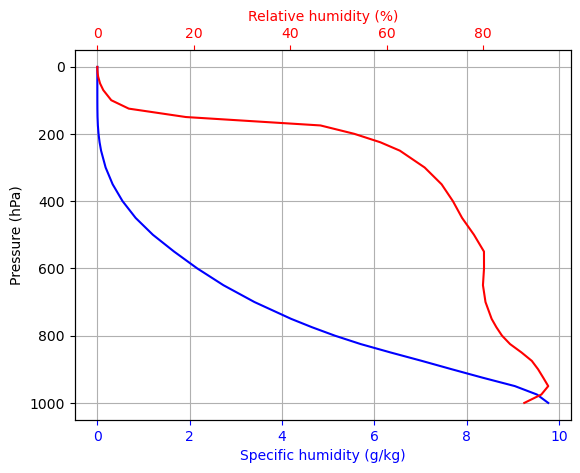

In [46]:
#  Plot relative humidity in percent
fig,ax = plt.subplots()
ax.plot(q*1000, rcm.lev, 'b-')
ax.invert_yaxis()
ax.grid()
ax.set_ylabel('Pressure (hPa)')
ax.set_xlabel('Specific humidity (g/kg)', color='b')
ax.tick_params('x', colors='b')
ax2 = ax.twiny()
ax2.plot(rh*100., rcm.lev, 'r-')
ax2.set_xlabel('Relative humidity (%)', color='r')
ax2.tick_params('x', colors='r')

In [47]:

# let's make a copy with doubled CO2
rcm_2xCO2_h2o = climlab.process_like(rcm_2xCO2)
rcm_2xCO2_h2o.name = 'Radiative-Convective Model (2xCO2 equilibrium with H2O feedback)'

### Constant RH RCE adjustment 

We loop and integrate step by step , resetting the RH to a constant value 

In [48]:
for n in range(2000):
    # At every timestep
    # we calculate the new saturation specific humidity for the new temperature
    #  and change the water vapor in the radiation model
    #  so that relative humidity is always the same
    qsat = climlab.utils.thermo.qsat(rcm_2xCO2_h2o.Tatm, rcm_2xCO2_h2o.lev)
    rcm_2xCO2_h2o.subprocess['Radiation'].specific_humidity[:] = rh * qsat
    rcm_2xCO2_h2o.step_forward()

In [49]:
# Check for energy balance
rcm_2xCO2_h2o.ASR - rcm_2xCO2_h2o.OLR

Field([-1.12283045e-05])

ok, let's take a look at the skew T

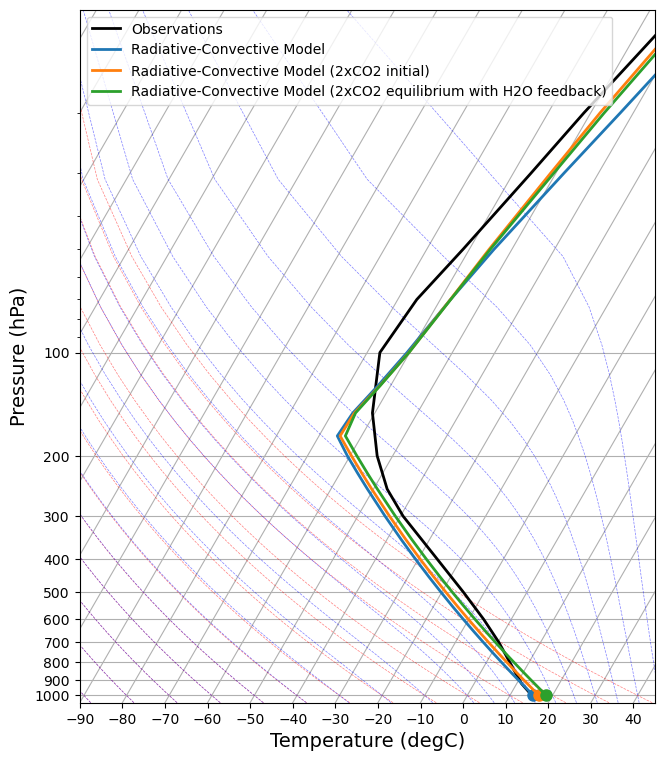

In [68]:
skew = make_skewT()
add_profile(skew, rcm)
add_profile(skew, rcm_2xCO2)
add_profile(skew, rcm_2xCO2_h2o)

In [52]:
ECS = rcm_2xCO2_h2o.Ts - rcm.Ts
ECS

Field([3.03513755])

In [59]:
g = ECS / ECS_nofeedback
g

Field([2.31598317])

In [67]:
f = 1-1/g[0]
print("f",f)
lambda_h20 = -f*lambda_bb
print ("lamba_h2o ",lambda_h20[0])

f 0.5682179340340348
lamba_h2o  1.8210473995473875


Conclusion, the water vapour feedback is similar in this model 